# BeforeIT surrogate model: complete analysis

This notebook documents the complete workflow from parameter discovery to surrogate validation. It separates the **revised global-screening study** from the **legacy eight-input pilot** already stored in this folder. The legacy results test the pipeline; they do not determine which parameters are important.

In [25]:
using Pkg

function find_repo(path=pwd())
    while !isfile(joinpath(path, "Project.toml"))
        parent = dirname(path)
        parent == path && error("Open this notebook from inside the BeforeIT repository")
        path = parent
    end
    path
end

repo = find_repo()
dirname(Base.active_project()) == repo || Pkg.activate(repo)
surrogate_dir = joinpath(repo, "dba-studies", "machine-learning", "surrogate")
data_dir = joinpath(surrogate_dir, "data")
results_dir = joinpath(surrogate_dir, "results")

import BeforeIT as Bit
using CSV, DataFrames, JLD2, Markdown, Plots, Statistics
include(joinpath(surrogate_dir, "surrogate_utils.jl"))

metrics (generic function with 1 method)

## 1. Complete parameter inventory

Every calibrated entry is retained in the audit. Structural dimensions are fixed. Scalar behavioral and policy parameters are independent candidates. Sector vectors and matrices remain grouped candidates because varying their cells independently would generally violate economic and accounting structure.

In [26]:
include(joinpath(surrogate_dir, "inventory_parameters.jl"))
inventory_table = inventory(Bit.AUSTRIA2010Q1.parameters)
CSV.write(joinpath(surrogate_dir, "parameter-inventory.csv"), inventory_table)
combine(groupby(inventory_table, :classification), nrow => :count)

Row,classification,count
,String,Int64
1,jointly_constrained_group_candidate,15
2,structural_dimension,10
3,independent_continuous_candidate,38


In [15]:
filter(:screening_eligible => identity, inventory_table)[:, [:parameter, :shape, :baseline, :classification, :source_usage]]

Row,parameter,shape,baseline,classification,source_usage
,String,String,String,String,String
1,C,3x3,"summary(min=4.3800671000101816e-5, max=0.0004506370179043619, mean=0.00022649823378423999)",jointly_constrained_group_candidate,src/model_init/init_properties.jl:88
2,a_sg,62x62,"summary(min=0.0, max=0.8149348034258406, mean=0.016129032258064516)",jointly_constrained_group_candidate,src/model_init/init_properties.jl:86
3,alpha_E,scalar,0.962809216044625,independent_continuous_candidate,src/model_init/init_rest_of_the_world.jl:16
4,alpha_G,scalar,0.9905949533296431,independent_continuous_candidate,src/model_init/init_government.jl:14
5,alpha_I,scalar,0.9662360466537488,independent_continuous_candidate,src/model_init/init_rest_of_the_world.jl:19
6,alpha_Y_EA,scalar,0.9635784504324201,independent_continuous_candidate,src/model_init/init_rest_of_the_world.jl:26
7,alpha_pi_EA,scalar,0.38456173629534834,independent_continuous_candidate,src/model_init/init_rest_of_the_world.jl:23
8,alpha_s,62x1,"summary(min=10.428169405250205, max=480.9225632826067, mean=62.18141530981933)",jointly_constrained_group_candidate,src/model_init/init_firms.jl:55
9,b_CFH_g,62x1,"summary(min=0.0, max=0.7262566916890253, mean=0.016129032258064516)",jointly_constrained_group_candidate,src/model_init/init_properties.jl:81


## 2. Range and constraint review

The table below proposes a mechanical ±20% interval only as a review aid. It is **not** an approved experimental domain. Each range must be checked against the parameter's equation, theoretical meaning, sign restrictions, probability bounds, and joint constraints before simulations begin.

In [16]:
scalar_candidates = filter(row -> row.screening_eligible && row.shape == "scalar", inventory_table)
range_review = select(scalar_candidates, :parameter, :baseline)
baseline_number = parse.(Float64, range_review.baseline)
range_review.lower_draft = min.(0.8 .* baseline_number, 1.2 .* baseline_number)
range_review.upper_draft = max.(0.8 .* baseline_number, 1.2 .* baseline_number)
range_review.status = fill("REVIEW REQUIRED", nrow(range_review))
range_review

Row,parameter,baseline,lower_draft,upper_draft,status
,String,String,Float64,Float64,String
1,alpha_E,0.962809216044625,0.770247,1.15537,REVIEW REQUIRED
2,alpha_G,0.9905949533296431,0.792476,1.18871,REVIEW REQUIRED
3,alpha_I,0.9662360466537488,0.772989,1.15948,REVIEW REQUIRED
4,alpha_Y_EA,0.9635784504324201,0.770863,1.15629,REVIEW REQUIRED
5,alpha_pi_EA,0.38456173629534834,0.307649,0.461474,REVIEW REQUIRED
6,beta_E,0.39260026877953946,0.31408,0.47112,REVIEW REQUIRED
7,beta_G,0.09373211872949586,0.0749857,0.112479,REVIEW REQUIRED
8,beta_I,0.35492769963078624,0.283942,0.425913,REVIEW REQUIRED
9,beta_Y_EA,0.5360029623199525,0.428802,0.643204,REVIEW REQUIRED


## 3. Global sensitivity screening

Use Morris elementary effects after ranges and grouped perturbations are approved. For parameter $j$:

$$\mu_j^*=\frac{1}{R}\sum_{r=1}^{R}|EE_{j,r}|$$

$$\sigma_j=\sqrt{\frac{1}{R-1}\sum_{r=1}^{R}(EE_{j,r}-\overline{EE}_j)^2}$$

High $\mu_j^*$ indicates overall influence; high $\sigma_j$ indicates nonlinear or interaction effects. Screening results should be compared with variation across random seeds and then spot-checked at full scale.

In [17]:
screening_path = joinpath(results_dir, "morris_screening.csv")
if isfile(screening_path)
    screening = CSV.read(screening_path, DataFrame)
    sort(screening, :mu_star, rev=true)
else
    md"**Not run yet.** Define and approve valid ranges and structure-preserving group perturbations first."
end

**Not run yet.** Define and approve valid ranges and structure-preserving group perturbations first.


## 4. Legacy pilot dataset diagnostics

The following cells inspect the existing eight-input pilot. They are useful for checking reproducibility, failures, stochastic replication, and target construction—not for final parameter selection.

In [18]:
runs_path = joinpath(data_dir, "raw_runs.csv")
runs = CSV.read(runs_path, DataFrame)
DataFrame(
    runs=nrow(runs),
    configurations=length(unique(runs.configuration_id)),
    successful=count(runs.success),
    failed=count(.!runs.success),
    median_runtime_seconds=median(runs.runtime_seconds),
)

Row,runs,configurations,successful,failed,median_runtime_seconds
,Int64,Int64,Int64,Int64,Float64
1,3,3,3,0,0.217725


In [19]:
targets = CSV.read(joinpath(data_dir, "configuration_targets.csv"), DataFrame)
describe(targets[:, TARGET_NAMES])

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,real_gdp_growth_12q,-0.0396286,-0.0587529,-0.0319958,-0.028137,0,Float64
2,mean_quarterly_real_gdp_growth,-0.00337802,-0.00504579,-0.00270991,-0.00237837,0,Float64
3,maximum_gdp_decline,0.0602983,0.0358636,0.0490564,0.0959747,0,Float64
4,mean_implicit_gdp_inflation,0.00380073,0.00362763,0.00384064,0.00393392,0,Float64
5,final_real_household_consumption,35445.7,32632.4,35649.8,38055.0,0,Float64
6,final_real_capitalformation,15368.1,14757.5,15277.2,16069.6,0,Float64
7,final_real_exports,34671.2,33695.8,35041.4,35276.2,0,Float64
8,final_real_imports,31615.7,29628.2,32011.2,33207.8,0,Float64
9,final_wages,28633.8,28062.9,28812.3,29026.2,0,Float64


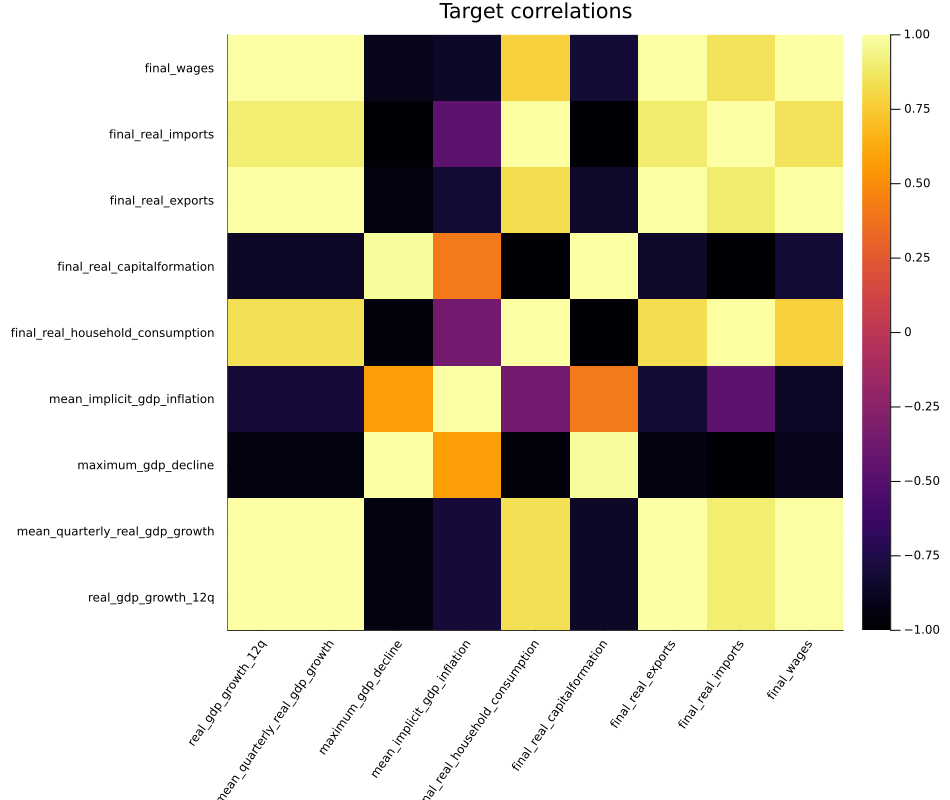

In [20]:
target_matrix = Matrix(targets[:, TARGET_NAMES])
heatmap(cor(target_matrix); xticks=(1:length(TARGET_NAMES), TARGET_NAMES), yticks=(1:length(TARGET_NAMES), TARGET_NAMES), xrotation=55, title="Target correlations", clims=(-1, 1), size=(950, 800))

## 5. Legacy linear-surrogate performance

In [21]:
metrics_table = CSV.read(joinpath(results_dir, "metrics.csv"), DataFrame)
sort(metrics_table, :nrmse)

Row,target,mae,nrmse,r2
,String,Float64,Float64,Float64
1,real_gdp_growth_12q,0.0168274,NaN,-Inf
2,mean_quarterly_real_gdp_growth,0.00146369,NaN,-Inf
3,maximum_gdp_decline,0.0159418,NaN,-Inf
4,mean_implicit_gdp_inflation,0.000258223,NaN,-Inf
5,final_real_household_consumption,223.051,NaN,-Inf
6,final_real_capitalformation,116.207,NaN,-Inf
7,final_real_exports,887.024,NaN,-Inf
8,final_real_imports,538.398,NaN,-Inf
9,final_wages,577.074,NaN,-Inf


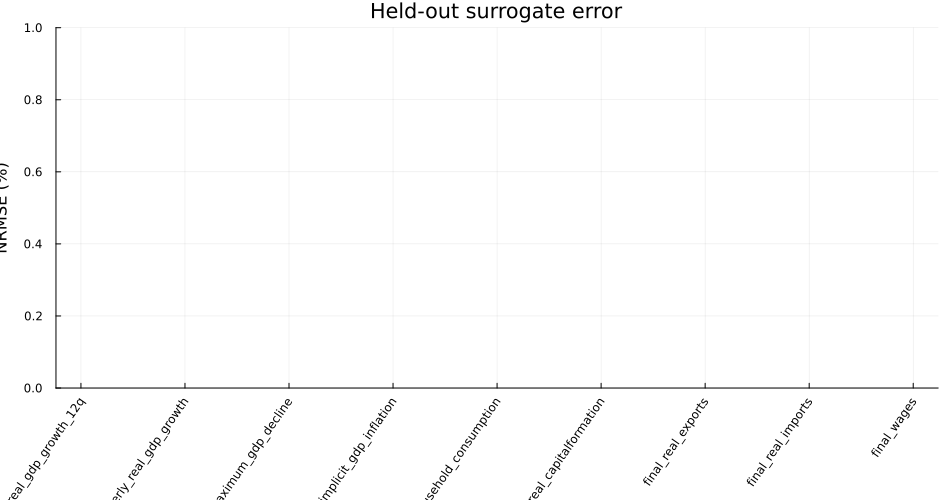

In [22]:
bar(metrics_table.target, 100 .* metrics_table.nrmse; ylabel="NRMSE (%)", label=false, xrotation=55, title="Held-out surrogate error", size=(950, 500))

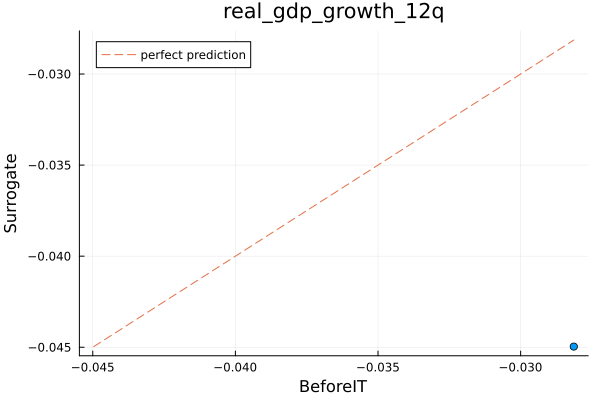

In [23]:
predictions = CSV.read(joinpath(results_dir, "test_predictions.csv"), DataFrame)
target = TARGET_NAMES[1]
scatter(predictions[!, "actual_$target"], predictions[!, "predicted_$target"]; xlabel="BeforeIT", ylabel="Surrogate", label=false, title=target)
lo, hi = extrema(vcat(predictions[!, "actual_$target"], predictions[!, "predicted_$target"]))
plot!([lo, hi], [lo, hi]; label="perfect prediction", linestyle=:dash)

## 6. Fresh-simulation validation

This compares stored surrogate predictions with simulations not used for fitting, when the validation artifact exists.

In [24]:
validation_path = joinpath(results_dir, "fresh_validation.csv")
isfile(validation_path) ? CSV.read(validation_path, DataFrame) : md"Fresh validation has not been run."

Row,target,prediction,lower_90,upper_90,simulation_mean,absolute_error
,String,Float64,Float64,Float64,Float64,Float64
1,real_gdp_growth_12q,-0.0470458,-0.0470458,-0.0470458,0.0472595,0.0943053
2,mean_quarterly_real_gdp_growth,-0.00402377,-0.00402377,-0.00402377,0.00378378,0.00780755
3,maximum_gdp_decline,0.0696742,0.0696742,0.0696742,0.0030819,0.0665923
4,mean_implicit_gdp_inflation,0.00389311,0.00389311,0.00389311,0.00245412,0.00143899
5,final_real_household_consumption,35005.0,35005.0,35005.0,41710.7,6705.77
6,final_real_capitalformation,15495.5,15495.5,15495.5,16666.6,1171.05
7,final_real_exports,34284.5,34284.5,34284.5,36515.5,2230.92
8,final_real_imports,31194.4,31194.4,31194.4,34150.7,2956.32
9,final_wages,28390.8,28390.8,28390.8,30548.4,2157.59


## 7. Decision gate

Do not train the final surrogate until all items below pass:

- all 63 calibration entries are classified and traced;
- valid scalar ranges and grouped perturbations are documented;
- Morris effects exceed stochastic noise for retained inputs;
- the shortlist is confirmed with full-scale spot checks;
- train/validation/test partitions are split by configuration;
- held-out error and uncertainty coverage meet the plan's acceptance gates.

Only after these checks should the selected inputs replace the legacy `PARAMETER_NAMES` list.